Where to go from here:

Scaling and resolution decisions first!


We should take the pictures, convert them, and then make a CSV for a finalized dataframe. This will significantly cut down on loading times for sessions.



Labeling issue: Assigned to Dylan Walker




* Data augmentation:

* We need to modify the downscale. We probably need to make it a square matrix first...

* Open CV it to get multiple bugs from one picture.

*

> Add blockquote



Notes/thoughts

Dylan's notes:

*   Try to get a pytorch CNN set up
*   We should talk and figure out how we want to proceed. (There was talk about using OpenCV. I think there are libraries that can do this in python.)
*   We should talk about how we want to train our models. (Do we need more pictures? How do we implement the pictures with multiple images?)
*   We will need to use our full set of pictures. (It may not hurt to create subfolders based on the images. This might make it easier to label them.)





### 1. Mount Google Drive
This step connects Google Colab to your Google Drive, allowing access to files stored there. You will be prompted to authorize this connection.

In [ ]:
# Import the drive module from google.colab
from google.colab import drive
# Mount Google Drive to the /content/drive directory
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Define Folder Path and List Contents
Here, we define the path to your 'SESSION 1' folder in Google Drive (assuming you've added a shortcut to 'My Drive'). Then, we list the first 5 items found in that folder to verify access. This system means we don't have to download the files locally.

In [ ]:
import os

# Define the path to the folder containing image files
folder_path = '/content/drive/MyDrive/SESSION 1' # Updated path after adding shortcut

# Initialize an empty list to store image filenames
images = None
# Check if the specified folder exists
if os.path.exists(folder_path):
    # If it exists, list all items (files and subfolders) within it
    images = os.listdir(folder_path)

    # Make it a list of file paths
    images = [os.path.join(folder_path, img) for img in images]

    print(f"Contents of '{folder_path}':")
    # Print the first 5 items found for a quick preview
    for item in images[:5]:
        print(item)
else:
    # If the folder does not exist, print an error message
    print(f"Error: The folder '{folder_path}' does not exist. Please verify the path and ensure the shortcut is in your 'My Drive'.")

Contents of '/content/drive/MyDrive/SESSION 1':
/content/drive/MyDrive/SESSION 1/5B7A9558.CR2
/content/drive/MyDrive/SESSION 1/5B7A9559.CR2
/content/drive/MyDrive/SESSION 1/5B7A9560.CR2
/content/drive/MyDrive/SESSION 1/5B7A9561.CR2
/content/drive/MyDrive/SESSION 1/5B7A9562.CR2


### 3. Define RAW to RGB Conversion Function
OpenCV doesn't work with RAW images so we have to use `rawpy` library to convert RAW image files (like `.CR2`) into a standard RGB format. There are a lot of options here for customization which I haven't played with.

In [ ]:
!pip install rawpy # I'm not sure if there's a better way to do this in colab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 33.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import rawpy

def raw_to_rgb(raw_img: os.path) -> np.float32:
  # Open the RAW image file using rawpy
  with rawpy.imread(raw_img) as raw:
      # Post-process the RAW image to an RGB format
      rgb = raw.postprocess(
        use_camera_wb=True,
        output_color=rawpy.ColorSpace.sRGB
      )

  return rgb

### 4. Define RGB to BGR Conversion Function
OpenCV typically works with images in BGR (Blue, Green, Red) channel order. This function converts an RGB image (common in `rawpy` output) to BGR format using OpenCV's color conversion capabilities.

### Note
However, there are many options for image formats, I am not sure what is best for our use case.

In [ ]:
import cv2

def rgb_to_bgr(rgb_img: np.float32) -> np.float32:
  # Convert an RGB image (float32 NumPy array) to BGR format
  bgr = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2BGR)
  return bgr

### 5. Define Comprehensive Preprocessing Function
This function orchestrates the entire preprocessing workflow for a RAW image. It first converts the RAW image to RGB using `raw_to_rgb`, and then converts the resulting RGB image to BGR using `rgb_to_bgr`, preparing it for further OpenCV operations.

In [ ]:
def preprocessing(raw_img: os.path) -> tuple[np.float32, np.float32]:
  # Convert the RAW image to RGB format
  rgb = raw_to_rgb(raw_img)
  # Convert the RGB image to BGR format (for OpenCV compatibility)
  bgr = rgb_to_bgr(rgb)
  return (bgr, rgb)

### 6. Process the First Image
Here, we apply the `preprocessing` function to the first image found in your `folder_path`. The result is stored in `processed_img`, which is now a BGR image ready for analysis.

In [ ]:
# Apply the preprocessing function to the first image in the list
first_img_path = images[0]
processed_img, rgb_img = preprocessing(first_img_path) # processed is in bgr

In [ ]:
#Dylan's Work. Feel free to change this to a markdown if you need to.

#print(processed_img)
print(rgb_img.shape)

(6744, 4502, 3)


In [ ]:
# Extracting the height and width of the processed image as a test
h, w = processed_img.shape[:2]
# Displaying the height and width values
print("Height = {}, Width = {}".format(h, w))

Height = 6744, Width = 4502


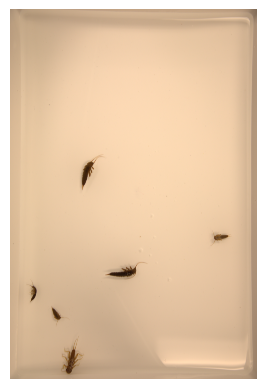

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(rgb_img)
plt.axis("off")
plt.show()

In [ ]:
#Dylan' again

import matplotlib.pyplot as plt

plt.imshow(rgb_img)
plt.axis("off")
plt.show()

In [ ]:
# Extracting RGB values.
# Here we have randomly chosen a pixel
# by passing in 100, 100 for height and width.
(B, G, R) = processed_img[100, 100]

# Displaying the pixel values
print("R = {}, G = {}, B = {}".format(R, G, B))

# We can also pass the channel to extract
# the value for a specific channel
B = processed_img[100, 100, 0]
print("B = {}".format(B))

R = 183, G = 157, B = 125
B = 125


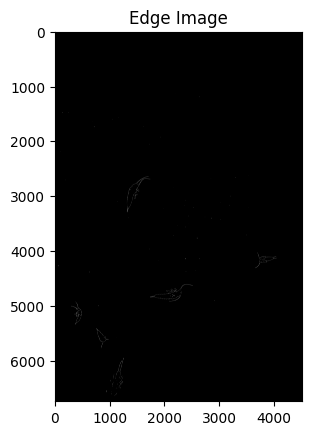

In [ ]:
gray_image = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(processed_img, 100, 200)
plt.imshow(edges, cmap='gray')
plt.title('Edge Image')
plt.show()

In [ ]:
def preprocessing(raw_img: os.path) -> np.float32:
  # Convert the RAW image to RGB format
  rgb = raw_to_rgb(raw_img)
  return rgb

In [ ]:
# Processing takes a long time, might make sense to store processed images somehow so we don't have to keep redoing

In [ ]:
import pandas as pd
from tqdm.notebook import tqdm

# Apply the preprocessing function to all images
processed_images = []
for img in tqdm(images, desc="Processing images"):
  rgb_img = preprocessing(img) # processed is in bgr

  processed_images.append(rgb_img)

df = pd.DataFrame({'rgb_img': processed_images, 'raw_img': images})

Processing images:   0%|          | 0/75 [00:00<?, ?it/s]

In [ ]:
#Dylan Walker I don't think we need to include the raw_img column. It may make more sense to quickly apply a



# This is the start of the alternate approach. Please feel free to read through this and use/modify it as you see fit.

Alternate approach. This can be run after you run everything up to 6.


Rough Y column for when we try to test the data.

cadis fly = 0
stone fly = 1
mayfly = 2
other =3

In [ ]:
'''
Wilson:

  I believe mayfly pictures are in the other folder which is currently not linked

  Also, I was wondering about doing the groups for this like shown in the NLP class. Might make it easier to check the data and work with specific species

  Ex:

      def get_vocab(texts, nlp):
          """Return set of unique lowercased token strings from texts."""
          if hasattr(texts, "tolist"):
              texts = texts.tolist()
          return {
              tok.text.lower()
              for doc in nlp.pipe((t for t in texts if isinstance(t, str)))
              for tok in doc
              if not tok.is_space
          }

      nlp = get_nlp()  # if you want this cell to be standalone
      promask_vocab = get_vocab(df.loc[df.group == "promask", "tweet_text"], nlp)
      antimask_vocab = get_vocab(df.loc[df.group == "antimask", "tweet_text"], nlp)
      combined_vocab = promask_vocab | antimask_vocab

      dict(
          promask=len(promask_vocab),
          antimask=len(antimask_vocab),
          combined=len(combined_vocab),
          shared=len(promask_vocab & antimask_vocab),
      )
'''

'\nWilson: \n\n  I believe mayfly pictures are in the other folder which is currently not linked\n\n  Also, I was wondering about doing the groups for this like shown in the NLP class. Might make it easier to check the data and work with specific species\n\n'

In [ ]:
#Here is a brute force version for session 1. Please note that I changed all group pictures to 3. We also don't have any mayfly pictures.
y = []
for i in range(0,14):
  y.append(3)
for i in range(14,45):
  y.append(1)
for i in range(45,56):
  y.append(3)
for i in range(56,75):
  y.append(0)
print(y)
print(len(y))

[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
75


In [ ]:
#This is a modification to what Wilson did. I went ahead and resized the images... and I didn't keep the raw image location.
import cv2
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

proIm=[]
for img in tqdm(images, desc="Processing images"):
  proIm.append(cv2.resize(raw_to_rgb(img), (224, 224), interpolation=cv2.INTER_AREA))

Processing images:   0%|          | 0/75 [00:00<?, ?it/s]

array([[[168, 143, 117],
        [170, 145, 119],
        [174, 148, 122],
        ...,
        [136, 113,  92],
        [134, 111,  91],
        [129, 109,  88]],

       [[171, 146, 119],
        [173, 147, 120],
        [176, 150, 123],
        ...,
        [139, 115,  94],
        [135, 112,  92],
        [131, 109,  89]],

       [[173, 148, 122],
        [175, 149, 123],
        [178, 152, 123],
        ...,
        [139, 115,  94],
        [135, 112,  92],
        [132, 111,  90]],

       ...,

       [[190, 162, 133],
        [189, 162, 133],
        [187, 160, 130],
        ...,
        [153, 129, 107],
        [151, 127, 105],
        [148, 124, 103]],

       [[185, 159, 129],
        [183, 157, 128],
        [181, 154, 127],
        ...,
        [152, 129, 105],
        [150, 126, 105],
        [147, 124, 103]],

       [[179, 153, 126],
        [177, 151, 124],
        [175, 150, 123],
        ...,
        [154, 130, 107],
        [149, 126, 104],
        [145, 123, 102]]], dtype=uint8)
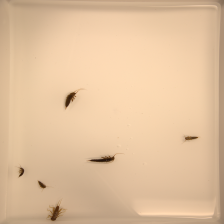

In [ ]:
'''
Wilson:

  I wonder what the image quality looks like after resizing since this is most likely just cutting away pixels.

  Looks less like cutting and more like stretching
'''

proIm[0]

In [ ]:
print(len(proIm))

75


In [ ]:
from sklearn.model_selection import train_test_split

# We normalized the values for our image.
X = []
for i in proIm:
  X.append(i.astype('float32') / 255.0)

# I need to double check this part.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.33,
    random_state=42,
    stratify=y
)


In [ ]:
print(X[:5])

[array([[[0.65882355, 0.56078434, 0.45882353],
        [0.6666667 , 0.5686275 , 0.46666667],
        [0.68235296, 0.5803922 , 0.47843137],
        ...,
        [0.53333336, 0.44313726, 0.36078432],
        [0.5254902 , 0.43529412, 0.35686275],
        [0.5058824 , 0.42745098, 0.34509805]],

       [[0.67058825, 0.57254905, 0.46666667],
        [0.6784314 , 0.5764706 , 0.47058824],
        [0.6901961 , 0.5882353 , 0.48235294],
        ...,
        [0.54509807, 0.4509804 , 0.36862746],
        [0.5294118 , 0.4392157 , 0.36078432],
        [0.5137255 , 0.42745098, 0.34901962]],

       [[0.6784314 , 0.5803922 , 0.47843137],
        [0.6862745 , 0.58431375, 0.48235294],
        [0.69803923, 0.59607846, 0.48235294],
        ...,
        [0.54509807, 0.4509804 , 0.36862746],
        [0.5294118 , 0.4392157 , 0.36078432],
        [0.5176471 , 0.43529412, 0.3529412 ]],

       ...,

       [[0.74509805, 0.63529414, 0.52156866],
        [0.7411765 , 0.63529414, 0.52156866],
        [0.73333335, 

In [ ]:
#I got gemini to give this to me. I'm using it more to see if everything is fitting together properly. We may want to use Pytorch instead.

import tensorflow as tf
from tensorflow.keras import layers, models

def create_cnn(input_shape=(224, 224, 3), num_classes=4):
    model = models.Sequential([
        # Convolutional Block 1
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        # Convolutional Block 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Convolutional Block 3
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Flatten and Dense layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5), # Helps prevent overfitting
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


In [ ]:
# This initializes the model and gives a summary.
model = create_cnn(input_shape=(224, 224, 3), num_classes=4)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# TensorFlow was being difficult. I had to convert the training and testing sets to np arrays.
X_train_np = np.array(X_train)
X_test_np = np.array(X_test)
y_train_np = np.array(y_train)
y_test_np = np.array(y_test)

print(X_train_np.shape)
print(y_train_np.shape)

print(X_train_np[0].shape)


(50, 224, 224, 3)
(50,)
(224, 224, 3)


In [ ]:
# Now we compile and train the data.

# Convert X_train and X_test from list of arrays to a single NumPy array



model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
history = model.fit(X_train_np, y_train_np, epochs=10,
                    validation_data=(X_test_np, y_test_np))

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:717: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.2358 - loss: 1.5578 - val_accuracy: 0.2400 - val_loss: 1.2506
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.3679 - loss: 1.5895 - val_accuracy: 0.4000 - val_loss: 1.1781
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.3783 - loss: 1.2489 - val_accuracy: 0.4000 - val_loss: 1.2610
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.4629 - loss: 1.2675 - val_accuracy: 0.4000 - val_loss: 1.1705
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.4258 - loss: 1.1395 - val_accuracy: 0.4000 - val_loss: 1.1450
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.2938 - loss: 1.3833 - val_accuracy: 0.4000 - val_loss: 1.1219
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 4s/step - accuracy: 0.3946 - loss: 1.1821 - val_accuracy: 0.4000 - val_loss: 1.1439
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.3546 - loss: 1.1911 - val_accuracy: 0.4000 - val_loss: 1.1392
Epoch 9/10
2/2 ━━━━━━━━━

In [ ]:
#This is just to see how the model actaully makes a prediction.
img = X_train_np[0]
img = np.expand_dims(img, axis=0)

a = model.predict(img)

max_index = np.argmax(a)
print(max_index)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1


It's worth mentioning that the prediction above was wrong. It should have been labeled a 3...